
Accuracy Comparision:
Decision Tree Accuracy: 0.45555555555555555
Random Forest Accuracy: 0.4666666666666667

Decision Tree Confusion Matrix:
 [[19 27]
 [22 22]]

Random Forest Confusion Matrix:
 [[21 25]
 [23 21]]


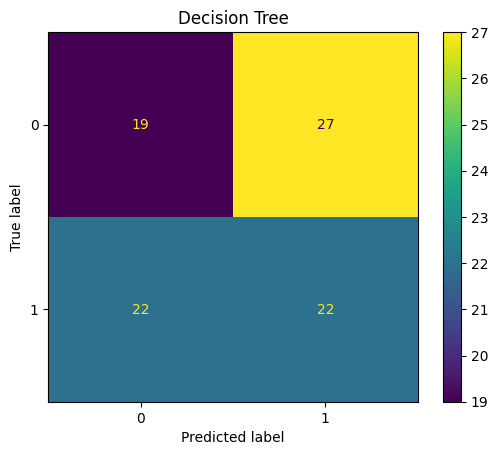

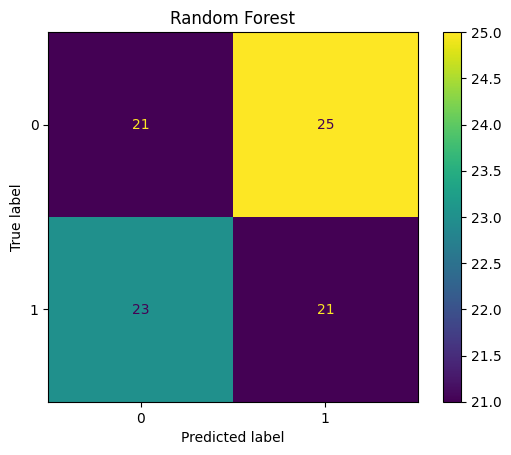


Cross Validation Accuracy:
Decision Tree: 0.5233333333333334
Random Forest: 0.53


In [ ]:
#1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay

#2
np.random.seed(42)
random.seed(42)
n_samples=300
data={
    'Weather':np.random.choie(['Sunny','Cloudy','Rainy'],n_samples),
    'Soil':np.random.choice(['dry','moist','wet'],n_samples),
    'Temperature':np.racndom.choice(['Hot','Mild','cool'],n_samples),
    'Humidity':np.random.choice(['high','medium','low'],n_samples),
    'Wind':np.random.choice(['strong','weak'],n_samples),
    'Fertilizer':np.random.choice(['Yes','No'],n_samples),
    'Crop Type':np.random.choice(['Wheat','Corn','Rice'],n_samples),
    'Season':np.random.choice(['Summer','Kharif','Rabi'],n_samples),
}
df=pd.DataFrame(data)

#3
def irrigation_rule(row):
 if row['Soil']=='Dry'and row['Weather']!='Rainy':
   base='Yes'
 elif row['Soil']=='Wet':
   base='No'
 else:
  base=random.choice(['Yes','No'])
#add noise(flip label with 20% probability)
 if random.random() < 0.2:
  return'No' if base=='Yes' else 'Yes'
 return base
df['Irrigation']=df.apply(irrigation_rule,axis=1)

#4
le=LabelEncoder()
for col in df.columns:
  df[col]=le.fit_transform(df[col])

#5
X=df.drop('Irrigation',axis=1)
Y=df['Irrigation']
X_train,X_test,Y_train,Y_test=train_test_split(
    X,Y,test_size=0.3,random_state=42,stratify=Y

)

#6
dt_model=DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_model.fit(X_train,Y_train)
Y_pred=dt_model.predict(X_test)

#7
rf_model=RandomForestClassifier(n_estimators=20,
                                max_features='sqrt',
                                random_state=42)
rf_model.fit(X_train,Y_train)
Y_pred_rf=rf_model.predict(X_test)


#8
df_accuracy=accuracy_score(Y_test,Y_pred)
rf_accuracy=accuracy_score(Y_test,Y_pred_rf)
print("\nAccuracy Comparision:")
print(f"Decision Tree Accuracy:",df_accuracy)
print("Random Forest Accuracy:",rf_accuracy)

#9
cm_dt=confusion_matrix(Y_test,Y_pred,labels=[0,1])
cm_rf=confusion_matrix(Y_test,Y_pred_rf,labels=[0,1])
print("\nDecision Tree Confusion Matrix:\n",cm_dt)
print("\nRandom Forest Confusion Matrix:\n",cm_rf)

#10
ConfusionMatrixDisplay.from_predictions(Y_test,Y_pred)
plt.title("Decision Tree")
plt.show()

ConfusionMatrixDisplay.from_predictions(Y_test,Y_pred_rf)
plt.title("Random Forest")
plt.show()

#11
dt_cv=cross_val_score(dt_model,X,Y,cv=5)
rf_cv=cross_val_score(rf_model,X,Y,cv=5)
print("\nCross Validation Accuracy:")
print("Decision Tree:",dt_cv.mean())
print("Random Forest:",rf_cv.mean())
